# A04: Model Interpretability (xAI)
-----------------------------------
**Madison Sobol**

You previously worked with this dataset on the 'Sampling' notebooks. Now, you will try to interpret the model!

You will build a classification model of your choice (you may use SMOTE or not - I'm not testing how good your model is for this assignment, just that you know how to interpret the model!). You must do some form of autoML or grid search...

The target variable is Loan_Status (thanks Ahmend for the heads-up!)

Then you will:
* Print the Top 5 features (using permutation importance with 20 repeats) in a box plot.
* Create the partial dependence plots for the top 5 features (you may opt to use the num_grid_points argument). Customize the plots so that the Y axis is consistent on each of the five plots.
* Write five meaningful bullets about what you see in the plots. Does anything surprise you? What do the X and Y axis mean in each plot?
  * Optional: Any issues with correlated predictors (read here for a cool way on how to address this: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html)?

In [ ]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.preprocessing import LabelEncoder

# Model evaluation
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

# Classification spot check models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Advanced ensemble models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier

# ICE
from pycebox.ice import ice, ice_plot

In [ ]:
#https://drive.google.com/file/d/1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W/view?usp=share_link
!gdown 1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W

Downloading...
From: https://drive.google.com/uc?id=1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W
To: /content/train_loan_imbalanced.csv
100% 38.0k/38.0k [00:00<00:00, 84.0MB/s]


In [ ]:
# Read data
df = pd.read_csv('/content/train_loan_imbalanced.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


##**Clean Data**

In [ ]:
# Drop unneeded column
df.drop('Loan_ID', axis=1, inplace=True)
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
# Check df shape
df.shape

(614, 12)

In [ ]:
# Inspect df for NaNs
df.isna().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [ ]:
# Drop any NaNs
df.dropna(inplace=True, axis=0)
print(df.shape) #eek ... decent amount of data removed

(480, 12)


In [ ]:
# Check for imbalances in loan status
df['Loan_Status'].value_counts() # data is imbalanced! for this assignmnet... its okay.

,count
Loan_Status,
Y,332
N,148


In [ ]:
# Label target variable
LE = LabelEncoder()
df['Loan_Status'] = LE.fit_transform(df['Loan_Status'])
Counter(df['Loan_Status'])

Counter({0: 148, 1: 332})

In [ ]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

##**Split Data**

In [ ]:
# Identify X and Y
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
validation_size = 0.20
seed = 123

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=validation_size,
                                                    random_state=seed)

In [ ]:
# Check training split
Counter(y_train)

Counter({1: 272, 0: 112})

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


##**Pipelines**

In [ ]:
# Label categorical variables for preprocessing
cols = df[['Gender', 'Married', 'Dependents','Education', 'Self_Employed','Credit_History','Property_Area']]
for col in cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])

In [ ]:
# Construct some pipelines for preprocessing
pipe_lr = Pipeline([('scl', StandardScaler()),
			('clf', LogisticRegression(random_state=123))])

pipe_knn = Pipeline([('scl', StandardScaler()),
			('clf', KNeighborsClassifier())])

pipe_dt = Pipeline([('scl', StandardScaler()),
			('clf', DecisionTreeClassifier(random_state=123))])

pipe_ada = Pipeline([('scl', StandardScaler()),
			('clf', AdaBoostClassifier(random_state=123))])

pipe_gb = Pipeline([('scl', StandardScaler()),
			('clf', GradientBoostingClassifier(random_state=123))])

pipe_rf = Pipeline([('scl', StandardScaler()),
			('clf', RandomForestClassifier(random_state=123))])

pipe_et = Pipeline([('scl', StandardScaler()),
			('clf', ExtraTreesClassifier(random_state=123))])

##**Grids**

In [ ]:
# Set grid search params
grid_params_lr = [{'clf__penalty': ['l1', 'l2'],
                  'clf__C': [1, 10],
                  'clf__solver': ['liblinear'],
                   'clf__max_iter': [1000000]}]

grid_params_knn = [{'clf__n_neighbors': [1, 3, 5, 10, 50]}]

grid_params_dt = [{'clf__criterion': ['gini', 'entropy'],
                  'clf__min_samples_leaf': [5, 10, 20, 25],
                  'clf__max_depth': [3, 5, 10, 15, 20],
                  'clf__min_samples_split': [5, 10, 20, 25]}]

grid_params_ada = [{'clf__n_estimators': [3, 5, 10, 15, 20],
		                'clf__learning_rate': [0.001, 0.01]}]

grid_params_gb = [{'clf__n_estimators': [3, 5, 10, 15, 20],
                'clf__learning_rate': [0.001, 0.01],
                'clf__loss': ['log_loss', 'exponential']}]

grid_params_rf = [{'clf__criterion': ['gini', 'entropy'],
                  'clf__min_samples_leaf': [5, 10, 20],
                  'clf__max_depth': [3, 5, 10, 15],
                  'clf__min_samples_split': [5, 10, 20],
                  'clf__n_estimators': [30, 50, 100, 200]}]

grid_params_et = [{'clf__criterion': ['gini', 'entropy'],
                  'clf__min_samples_leaf': [5, 10, 20],
                  'clf__max_depth': [3, 5, 10, 15],
                  'clf__min_samples_split': [5, 10, 20],
                  'clf__n_estimators': [30, 50, 100, 200]}]



In [ ]:
# Construct grid searches.. will run through every potential combination of parameters to find the best combination
gs_lr = GridSearchCV(estimator=pipe_lr,
    param_grid=grid_params_lr,
    scoring='accuracy',
    cv=10)

gs_knn = GridSearchCV(estimator=pipe_knn,
    param_grid=grid_params_knn,
    scoring='accuracy',
    cv=10)

gs_dt = GridSearchCV(estimator=pipe_dt,
    param_grid=grid_params_dt,
    scoring='accuracy',
    cv=10)

gs_ada = GridSearchCV(estimator=pipe_ada,
    param_grid=grid_params_ada,
    scoring='accuracy',
    cv=10)

gs_gb = GridSearchCV(estimator=pipe_gb,
    param_grid=grid_params_gb,
    scoring='accuracy',
    cv=10)

gs_rf = GridSearchCV(estimator=pipe_rf,
    param_grid=grid_params_rf,
    scoring='accuracy',
    cv=10)

gs_et = GridSearchCV(estimator=pipe_et,
    param_grid=grid_params_et,
    scoring='accuracy',
    cv=10)

# List of pipelines for ease of iteration
grids = [gs_knn, gs_dt, gs_ada, gs_gb, gs_rf, gs_et]

# Dictionary of pipelines and classifier types for ease of reference
grid_dict = {0: 'KNN',
             1: 'DTC',
             2: 'ADA',
             3: 'GBC',
             4: 'RFC',
             5: 'ET'}


In [ ]:
# Fit the grid search objects
print('Performing model optimizations...')
best_acc = 0.0
best_clf = 0
best_gs = ''
for idx, gs in enumerate(grids):
	print('\nEstimator: %s' % grid_dict[idx])
	# Fit grid search
	gs.fit(X_train, y_train)
	# Best params
	print('Best params: %s' % gs.best_params_)
	# Best training data accuracy
	print('Best training accuracy: %.3f' % gs.best_score_)
	# Predict on test data with best params
	y_pred = gs.predict(X_test)
	# Test data accuracy of model with best params
	print('Test set accuracy score for best params: %.3f ' % accuracy_score(y_test, y_pred))
	# Track best (highest test accuracy) model
	if accuracy_score(y_test, y_pred) > best_acc:
		best_acc = accuracy_score(y_test, y_pred)
		best_gs = gs
		best_clf = idx
print('\nClassifier with best test set accuracy: %s' % grid_dict[best_clf])


Performing model optimizations...

Estimator: KNN
Best params: {'clf__n_neighbors': 10}
Best training accuracy: 0.799
Test set accuracy score for best params: 0.792 

Estimator: DTC
Best params: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 20, 'clf__min_samples_split': 5}
Best training accuracy: 0.815
Test set accuracy score for best params: 0.781 

Estimator: ADA
Best params: {'clf__learning_rate': 0.001, 'clf__n_estimators': 3}
Best training accuracy: 0.815
Test set accuracy score for best params: 0.781 

Estimator: GBC
Best params: {'clf__learning_rate': 0.001, 'clf__loss': 'log_loss', 'clf__n_estimators': 3}
Best training accuracy: 0.708
Test set accuracy score for best params: 0.625 

Estimator: RFC
Best params: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 5, 'clf__n_estimators': 30}
Best training accuracy: 0.815
Test set accuracy score for best params: 0.781 

Estimator: ET
Best params: {'clf__cr

/tmp/ipykernel_689/2462550277.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,


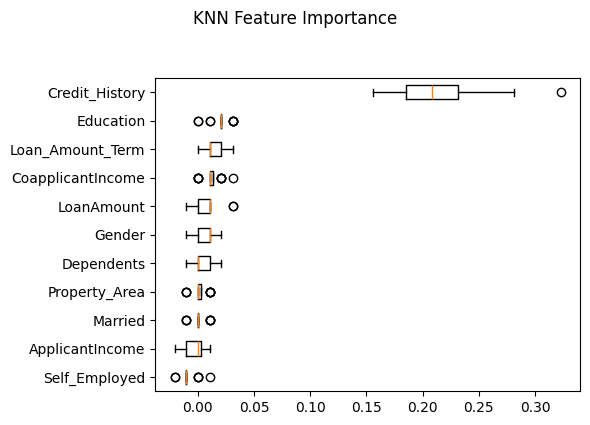

In [ ]:
# Perform permutation importance on best model
clf = best_gs

result = permutation_importance(clf, X_test, y_test, n_repeats=20,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
fig.suptitle('KNN Feature Importance', y=1.05)
fig.tight_layout()
plt.show()

In [ ]:
# Creating df for ICE and PDP
train_X_df = pd.DataFrame(X_train, columns=X.columns)
train_X_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
364,1,0,0,0,1,6822,0.0,141.0,360.0,1,0
354,0,1,0,0,0,2423,505.0,130.0,360.0,1,1
169,1,1,2,0,0,8000,0.0,200.0,360.0,1,1
441,1,1,0,0,0,7901,1833.0,180.0,360.0,1,0
26,1,1,0,0,0,2799,2253.0,122.0,360.0,1,1


In [ ]:
# Predict for top 5 features
tmpdf = ice(data=train_X_df, # ice needs a dataframe
            column='Credit_History', # the column name
                   predict=best_gs.predict) # the predict statement from the
                                          # model
tmpdf2 = ice(data=train_X_df, # ice needs a dataframe
            column='Education', # the column name
                   predict=best_gs.predict) # the predict statement from the
                                          # model
tmpdf3 = ice(data=train_X_df, # ice needs a dataframe
            column='Loan_Amount_Term', # the column name
                   predict=best_gs.predict) # the predict statement from the
                                          # model
tmpdf4 = ice(data=train_X_df, # ice needs a dataframe
            column='CoapplicantIncome', # the column name
                   predict=best_gs.predict) # the predict statement from the
                                          # model
tmpdf5 = ice(data=train_X_df, # ice needs a dataframe
            column='LoanAmount', # the column name
                   predict=best_gs.predict) # the predict statement from the
                                          # model

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


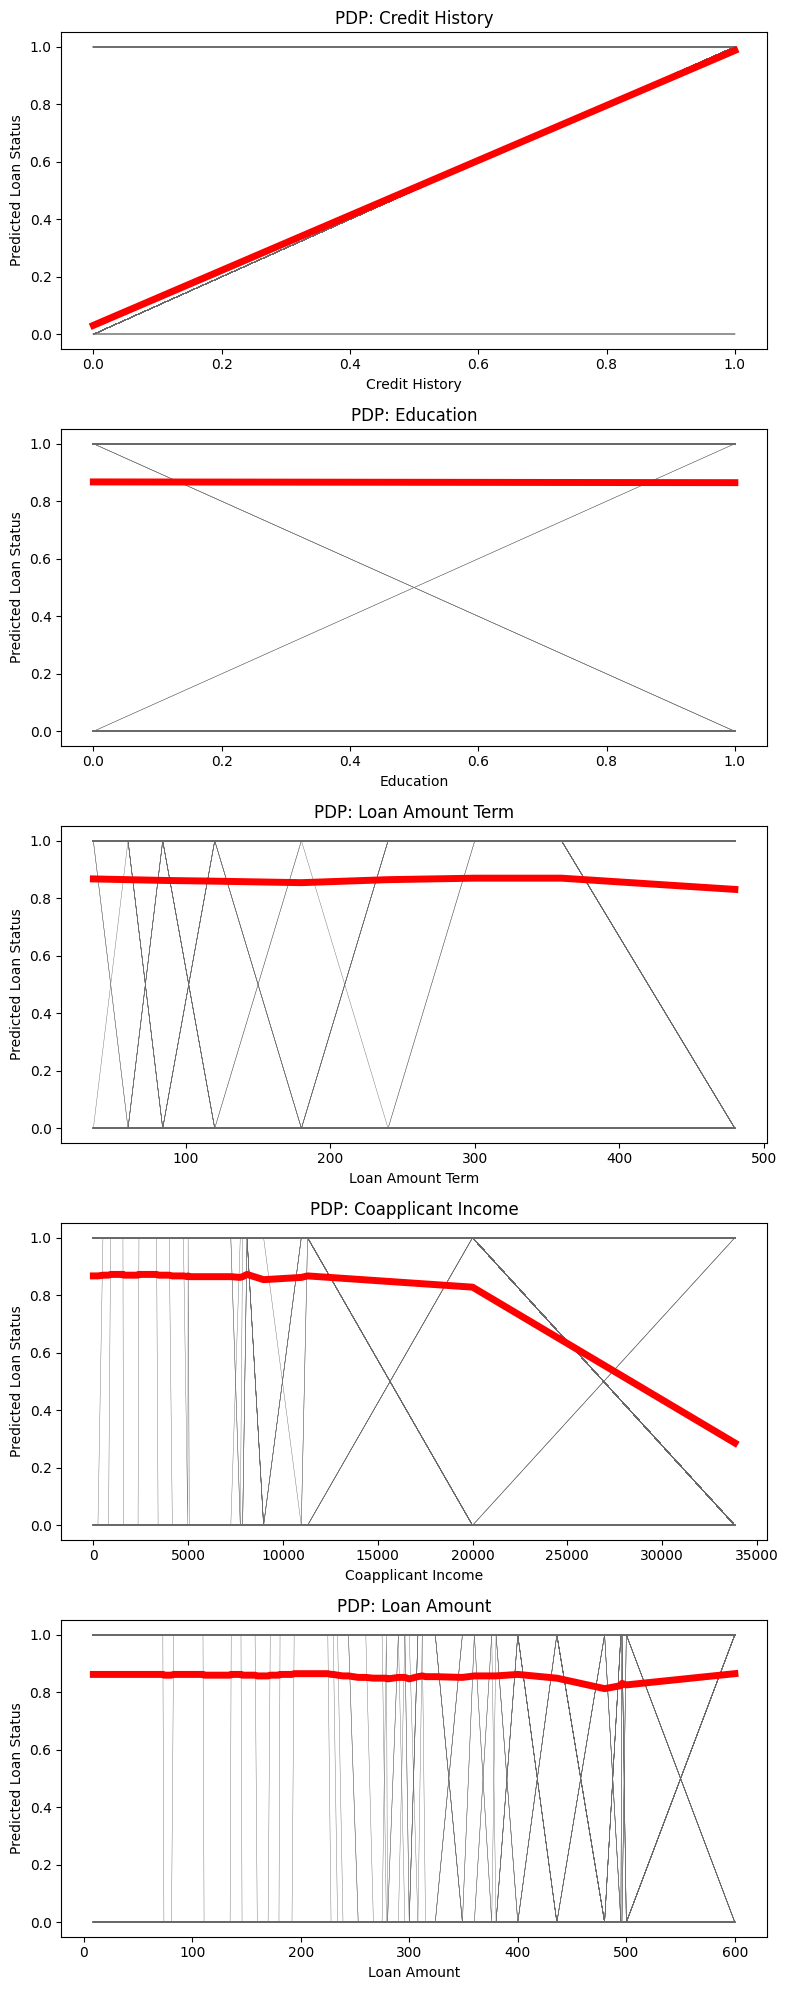

In [28]:
# Plot ICE and PDP for top 5 features
fig, axes = plt.subplots(ncols=1, nrows=5, figsize=(8, 20), tight_layout=True)

ice_plot(tmpdf, ax=axes[0],
         c='dimgray', linewidth=0.3,
         plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color': 'red'})
axes[0].set_title('PDP: Credit History')
axes[0].set_ylabel('Predicted Loan Status')
axes[0].set_xlabel('Credit History')

ice_plot(tmpdf2, ax=axes[1],
         c='dimgray', linewidth=0.3,
         plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color': 'red'})
axes[1].set_title('PDP: Education')
axes[1].set_ylabel('Predicted Loan Status')
axes[1].set_xlabel('Education')

ice_plot(tmpdf3, ax=axes[2],
         c='dimgray', linewidth=0.3,
         plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color': 'red'})
axes[2].set_title('PDP: Loan Amount Term')
axes[2].set_ylabel('Predicted Loan Status')
axes[2].set_xlabel('Loan Amount Term')

ice_plot(tmpdf4, ax=axes[3],
         c='dimgray', linewidth=0.3,
         plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color': 'red'})
axes[3].set_title('PDP: Coapplicant Income')
axes[3].set_ylabel('Predicted Loan Status')
axes[3].set_xlabel('Coapplicant Income')

ice_plot(tmpdf5, ax=axes[4],
         c='dimgray', linewidth=0.3,
         plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color': 'red'})
axes[4].set_title('PDP: Loan Amount')
axes[4].set_ylabel('Predicted Loan Status')
axes[4].set_xlabel('Loan Amount')


plt.show()

In [ ]:
#Conclusive thoughts and observations
#1) Here, I have plotted the top 5 features identified in my feature importance plot. The x axes are credit history, education, loan amount term, coapplicant income, and loan amount. The y axis for all 5 subplots is the predicted loan status, with the red line indicating the average outcome (PDP).
#2) These figures do not look like how I expected them to based on the examples covered in the course. Since my loan status was label encoded to be 0 or 1, the predicted loan status value is limited to be 0 or 1 regardless of the feature values. As a result, my ICE looks very choppy.
#3) Features such as education and credit history were also label encoded in order to scale the values. As a result, they also only have two unique values (0 or 1), which produces a very simplistic plot with a linear PDP.
#4) Plots with numerical features such as coapplicant income and loan amount display a higher number of predictions since there are more unique values to predict with. The PDP is also less linear compared to the plots of categorical features.
#5) While the PDP should generally provide information on how the feature of interest impacts the predicted outcome, I have concerns about the categorical data. If there are limited unique values to predict on, I do not think I can confidently state the relationship between the feature and predicted loan status. I have more trust in the PDP of numerical features and the predicted outcome.